In [1]:
import arviz as az
import bayesflow as bf
import blackjax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from confrdm.data import load_hdf5
from confrdm_jax.plots import  plot_data_hist

INFO:2026-02-06 16:51:50,682:jax._src.xla_bridge:834: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


## RDM

In [2]:
def reshape_posterior_samples(samples):
    return np.reshape(samples, (samples.shape[0], -1, samples.shape[-1]))

In [3]:
results = load_hdf5("../outputs/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=500000/parameter_recovery_hierarchical.hdf5")

In [10]:
posterior_samples_chains_approx = np.moveaxis(results["pop0_samples_ref"], 0, 1)
posterior_samples_approx = np.reshape(posterior_samples_chains_approx, (-1, posterior_samples_chains_approx.shape[-1]))
posterior_samples_approx.shape

(2000, 58)

In [11]:
results["pop0_pop_params_true"]

array([0.78762388, 0.59659755, 2.37153792, 0.02552822, 0.10990548,
       0.10414341, 0.21904626, 0.10792811])

In [12]:
results["pop0_subj_params_true"]

array([[0.5000559 , 1.9716773 , 1.549937  , 0.57481825, 0.3323651 ],
       [1.0017223 , 2.2422948 , 0.99390364, 0.5181051 , 0.4036525 ],
       [0.5988379 , 6.913712  , 1.4197544 , 0.53651077, 0.22696842],
       [0.7751522 , 2.0952942 , 1.5784134 , 0.6146057 , 0.39240533],
       [1.6529539 , 1.0114862 , 1.4570757 , 0.40516055, 0.17378545],
       [0.4691791 , 2.5014231 , 1.6082467 , 0.7006912 , 0.19101502],
       [2.035177  , 0.5632853 , 0.6529741 , 0.9241014 , 0.04163162],
       [0.3503042 , 0.5740465 , 1.1225207 , 0.3713891 , 0.20618977],
       [1.9318783 , 0.6349434 , 1.1051979 , 0.48896465, 0.2659365 ],
       [0.05802292, 5.0997767 , 1.0235474 , 0.7728689 , 0.2403076 ]],
      dtype=float32)

In [13]:
posterior_samples_approx[0, :8]

array([0.39137983, 1.0438237 , 2.7627428 , 1.7970123 , 0.11037715,
       0.07933065, 0.24222064, 0.10885842], dtype=float32)

In [14]:
posterior_samples_approx[:, 8:].shape

(2000, 50)

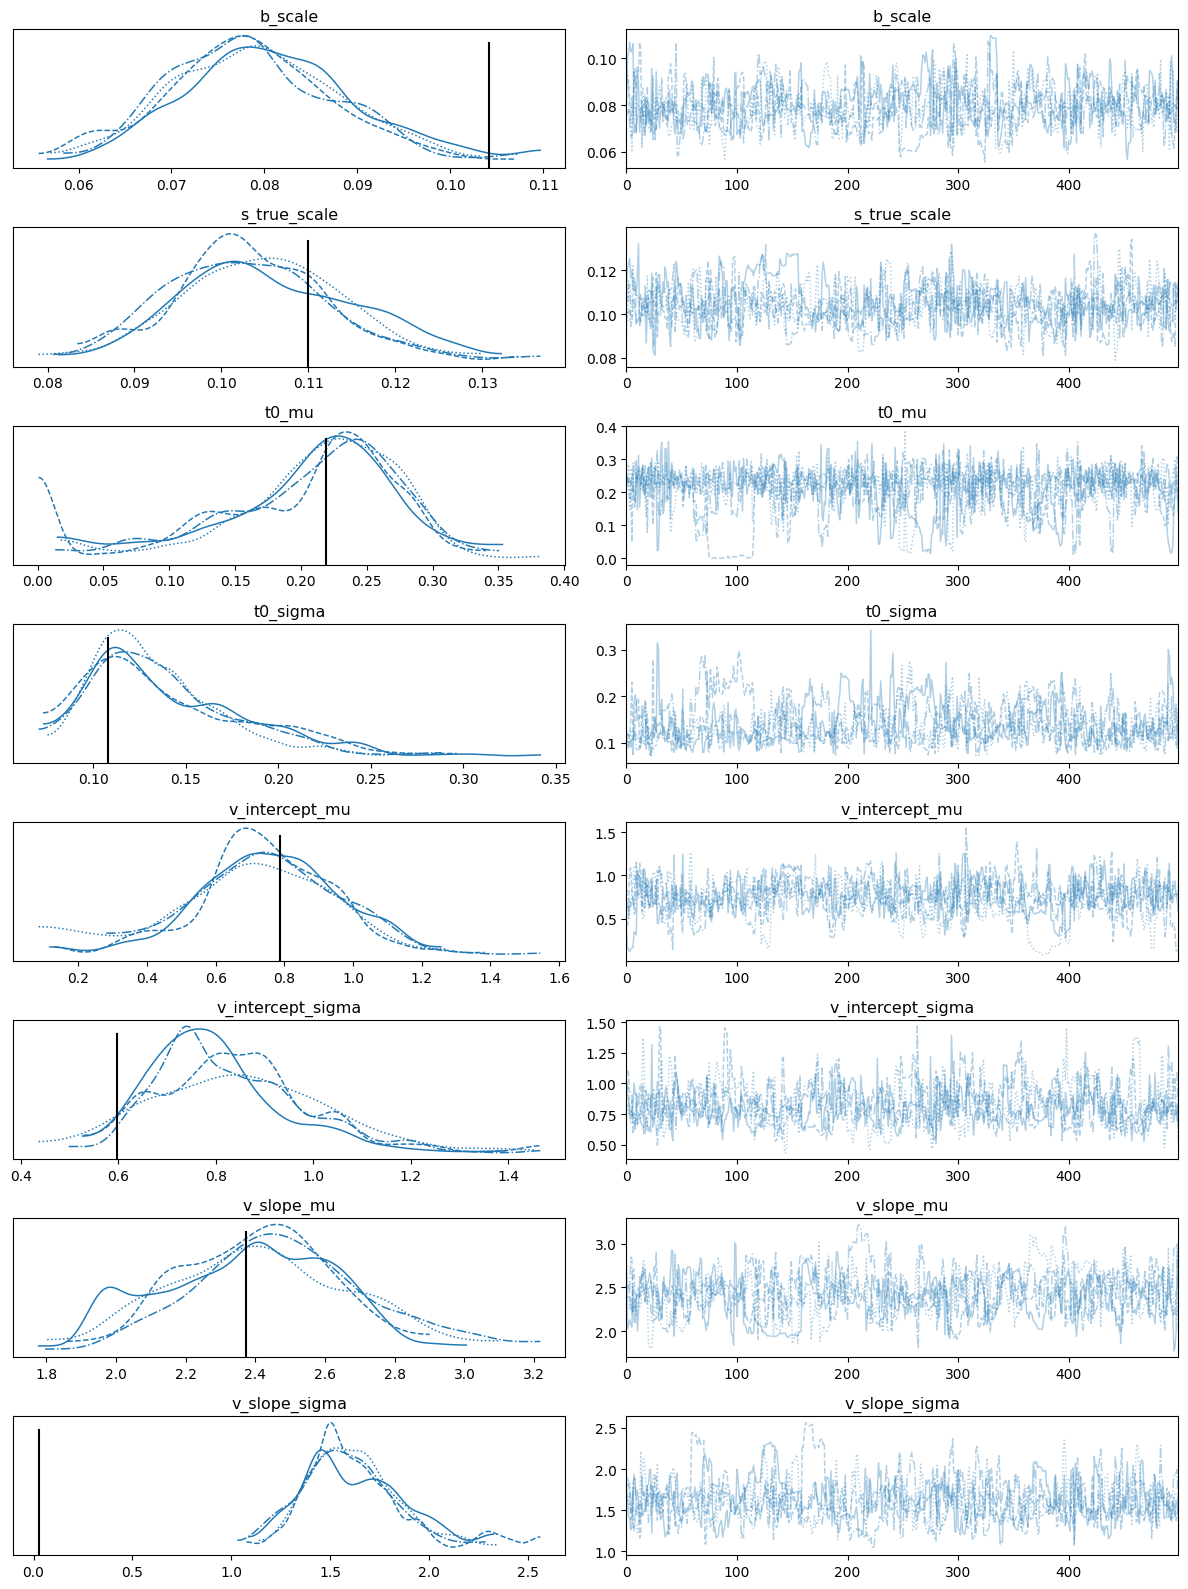

In [15]:
param_names = ["v_intercept_mu", "v_intercept_sigma", "v_slope_mu", "v_slope_sigma", "s_true_scale", "b_scale", "t0_mu", "t0_sigma"]

idata = az.convert_to_inference_data(
    {key: val for key, val in zip(param_names, np.moveaxis(posterior_samples_chains_approx, -1, 0)[:8])}
)

ax = az.plot_trace(idata)

true_params = {key:val for key, val in zip(param_names, results["pop0_pop_params_true"])}

for i, key in enumerate(sorted(true_params)):
    ax[i, 0].axvline(true_params[key], 0, 0.9, color="k")

plt.tight_layout()

In [19]:
results["pop0_subj_params_true"].shape

(10, 5)

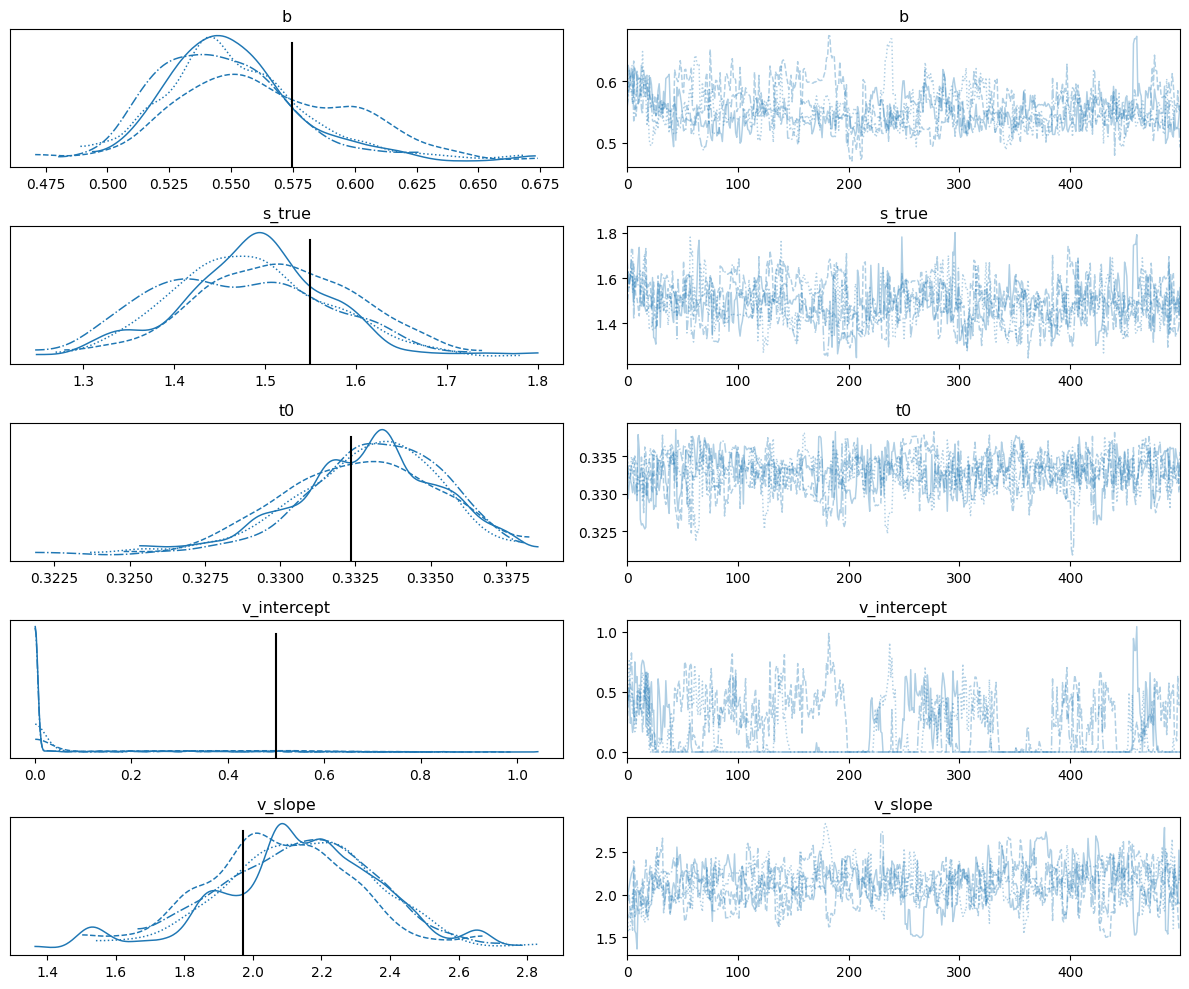

In [20]:
param_names = ["v_intercept", "v_slope", "s_true", "b", "t0"]

idata = az.convert_to_inference_data(
    {key: val for key, val in zip(param_names, np.moveaxis(posterior_samples_chains_approx, -1, 0)[8:13])}
)

ax = az.plot_trace(idata)

true_params = {key:val for key, val in zip(param_names, results["pop0_subj_params_true"][0])}

for i, key in enumerate(sorted(true_params)):
    ax[i, 0].axvline(true_params[key], 0, 0.9, color="k")

plt.tight_layout()